# TOST equivalence analysis for the setup and finger null effects

**Standalone.** This notebook reads the per-participant PSE/JND fits written by the
psychophysics pipeline (`analysis/psychophysics/results/L_N_E/csv/all/shared/`) and does
not import anything from `anova_statistics`. Run it with the system Python (pandas, scipy,
pingouin, statsmodels, matplotlib).

**Goal.** Replace "*p* > .05, therefore flexible finger selection" with "the difference,
if any, is smaller than a perceptually meaningful amount" (Lakens, 2017).

**Cohort.** Participants whose raw-data folder is tagged `(filter)` are excluded from every
analysis (L_E_19, N_E_17), giving N = 39 (20 air-slide, 19 natural). Unequal groups are
handled by Welch's *t* with Welch-Satterthwaite df (Delacre, Lakens & Leys, 2017), the form
Lakens (2017, eq. 3-4) uses for the two-sample TOST.

| Step | What | Where |
|---|---|---|
| 0 | Per-participant fits exist and agree with the pooled fits | `step0` |
| 1 | Pre-specified bounds in perceptual units | constants in the module |
| 2 | Feasibility: can the 90% CI fit inside the bound at all? | `step2` |
| 3 | TOST: Welch (setup), paired + Holm (finger pairs), one-sample (bias vs 0) | `setup`, `pairs`, `zero` |
| 4 | Bayes factors: JZS for setup and finger pairs; JASP export for omnibus inclusion BFs | `bf_ttest`, `bf_pairs`, `for_jasp_wide.csv` |
| 5 | Minimal detectable effect at 80% power | `mde` |


In [1]:
import os, warnings, importlib
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)
import tost_equivalence as T
T = importlib.reload(T)
print("data:", T.DATA_PATH)
print("excluded:", T.excluded_subjects())
df = T.load_fits()
sm = T.subject_means(df, "Bias")
print(f"N = {df.Subject.nunique()} participants: {int((sm.System=='L').sum())} air-slide, {int((sm.System=='N').sum())} natural; {len(df)} fits")


data: C:\Users\user\BIO MEDICAL ROBOTICS Dropbox\Elisheva Shiri Decktor\BGU\Codes\Parallel_Heptics\analysis\psychophysics\results\L_N_E\csv\all\shared\pse_jnd_by_subject_finger.csv
excluded: ('L_E_19', 'N_E_17')
N = 39 participants: 20 air-slide, 19 natural; 156 fits


## Step 0. Per-participant fits and consistency with the pooled fits

One 4-parameter logistic fit per participant x finger (64 trials each). The per-participant
mean/median bias and JND are shown next to the pooled group fit for the same finger. Pooled
fits and per-participant means need not coincide (a pooled fit is not the mean of individual
fits), but they should tell the same story; the paper's Table III should be labelled as one or
the other, not both.

In [2]:
step0 = T.step0_consistency(df)
display(step0.round(2))
jnd_ref = T.jnd_reference(df)
print(f"Median per-participant JND (anchor for the bias bound): {jnd_ref:.2f} mm/m")


,Finger,n fits,trials/fit,Bias mean,Bias SD,Bias median,Bias IQR,JND mean,JND SD,JND median,JND IQR,pooled bias,pooled JND,pooled trials
0,Index,39,64,0.18,1.21,0.33,"[-0.83, 1.10]",2.27,1.96,1.59,"[1.01, 2.74]",0.05,2.61,2560
1,Middle,39,64,0.33,1.26,0.27,"[-0.43, 1.15]",2.93,2.64,2.33,"[1.19, 4.45]",-0.07,2.71,2496
2,Ring,39,64,-0.11,1.33,0.10,"[-1.42, 0.88]",1.74,1.56,1.53,"[0.28, 2.17]",-0.03,2.41,2560
3,Little,39,64,0.01,1.48,0.25,"[-1.26, 1.03]",2.19,2.48,1.36,"[0.87, 2.85]",-0.23,2.36,2560


Median per-participant JND (anchor for the bias bound): 1.61 mm/m


## Step 1. Pre-specified bounds (perceptual units)

* **PSE bias:** +/-1 JND = **+/-1.6 mm/m** (primary). Two conditions whose PSEs differ by less
  than one JND are, by construction, indistinguishable to the participants themselves.
  Secondary, stricter bound: +/-0.5 JND = +/-0.8 mm/m.
* **JND:** a difference matters if it changes usable resolution: **+/-0.5 mm/m** (~30% of the
  JND) on the raw scale, and a **x1.30 ratio** on the log scale (JND is a scale parameter, so
  ratio bounds are the natural alternative and also tame the heavy right tail).

These are fixed constants in the module and were set before the TOST outcome was read.

In [3]:
print("SESOI bias:", T.SESOI_BIAS, "| SESOI JND abs:", T.SESOI_JND_ABS, "| JND ratio:", T.SESOI_JND_RATIO)

SESOI bias: {'1 JND': 1.6, '0.5 JND': 0.8} | SESOI JND abs: 0.5 | JND ratio: 1.3


## Step 2. Feasibility

Before reading any TOST outcome: with the observed SDs and the actual group sizes, is the 90% CI
half-width smaller than the bound? If not, the TOST cannot pass even when the true effect is zero,
and the honest framing is "inconclusive at the perceptual bound", not a widened bound.

In [4]:
step2 = T.step2_feasibility(df)
display(step2.round(2))


,DV,comparison,n,SD,ci90_halfwidth,bound,bound_name,feasible
0,Bias,"Setup, per participant",20 vs 19,0.76 / 0.56,0.36,1.60,1 JND,True
1,Bias,"Setup, per participant",20 vs 19,0.76 / 0.56,0.36,0.80,0.5 JND,True
2,Bias,"Finger pairs (paired), median SD of diffs",39,1.87,0.51,1.60,1 JND,True
3,Bias,"Finger pairs (paired), median SD of diffs",39,1.87,0.51,0.80,0.5 JND,True
4,Bias,"Bias vs 0, Index",39,1.21,0.33,1.60,1 JND,True
5,Bias,"Bias vs 0, Index",39,1.21,0.33,0.80,0.5 JND,True
6,Bias,"Bias vs 0, Middle",39,1.26,0.34,1.60,1 JND,True
7,Bias,"Bias vs 0, Middle",39,1.26,0.34,0.80,0.5 JND,True
8,Bias,"Bias vs 0, Ring",39,1.33,0.36,1.60,1 JND,True
9,Bias,"Bias vs 0, Ring",39,1.33,0.36,0.80,0.5 JND,True


## Step 3. The tests

* **Setup** (between, 20 vs 19): Welch two-sample TOST on the per-participant mean and per finger.
* **Finger** (within, 4 levels): six paired TOSTs with Holm correction; the Finger factor is
  called equivalent only if all six pass.
* **Bias vs 0** per finger: one-sample TOST.

Every `p_tost` is cross-checked against `pingouin.tost` (`p_tost_pingouin`). Outcomes are named
with Lakens' four scenarios (A equivalent and not different ... D undetermined).

In [5]:
setup = T.step3_setup(df)
cols = ["DV", "bound", "unit", "n1", "n2", "estimate", "ci90_lo", "ci90_hi", "df", "p_tost", "p_tost_pingouin", "equivalent", "p_nhst", "outcome"]
display(setup[cols].round(3))


,DV,bound,unit,n1,n2,estimate,ci90_lo,ci90_hi,df,p_tost,p_tost_pingouin,equivalent,p_nhst,outcome
0,Bias,bias +/-1.6 (1 JND),per participant,20,19,0.255,-0.105,0.614,34.930,0.000,0.000,True,0.239,"A: equivalent, not different"
1,Bias,bias +/-1.6 (1 JND),Index,20,19,-0.266,-0.930,0.399,35.204,0.001,0.001,True,0.504,"A: equivalent, not different"
2,Bias,bias +/-1.6 (1 JND),Middle,20,19,0.514,-0.156,1.184,34.136,0.005,0.005,True,0.204,"A: equivalent, not different"
3,Bias,bias +/-1.6 (1 JND),Ring,20,19,0.628,-0.076,1.333,36.961,0.013,0.013,True,0.141,"A: equivalent, not different"
4,Bias,bias +/-1.6 (1 JND),Little,20,19,0.142,-0.661,0.945,32.652,0.002,0.002,True,0.766,"A: equivalent, not different"
5,Bias,bias +/-0.8 (0.5 JND),per participant,20,19,0.255,-0.105,0.614,34.930,0.007,0.007,True,0.239,"A: equivalent, not different"
6,Bias,bias +/-0.8 (0.5 JND),Index,20,19,-0.266,-0.930,0.399,35.204,0.091,0.091,False,0.504,D: undetermined
7,Bias,bias +/-0.8 (0.5 JND),Middle,20,19,0.514,-0.156,1.184,34.136,0.237,0.237,False,0.204,D: undetermined
8,Bias,bias +/-0.8 (0.5 JND),Ring,20,19,0.628,-0.076,1.333,36.961,0.342,0.342,False,0.141,D: undetermined
9,Bias,bias +/-0.8 (0.5 JND),Little,20,19,0.142,-0.661,0.945,32.652,0.088,0.088,False,0.766,D: undetermined


In [6]:
pairs = T.step3_finger_pairs(df)
cols = ["DV", "bound", "pair", "n", "estimate", "ci90_lo", "ci90_hi", "p_tost", "p_tost_holm", "equivalent_holm", "p_nhst", "outcome"]
display(pairs[cols].round(3))
verdict = T.finger_factor_verdict(pairs)
print("Finger factor verdict (all six pairs must pass after Holm):")
display(verdict.round(3))


,DV,bound,pair,n,estimate,ci90_lo,ci90_hi,p_tost,p_tost_holm,equivalent_holm,p_nhst,outcome
0,Bias,bias +/-1.6 (1 JND),Index-Middle,39,-0.151,-0.636,0.333,0.000,0.000,True,0.602,"A: equivalent, not different"
1,Bias,bias +/-1.6 (1 JND),Index-Ring,39,0.291,-0.144,0.726,0.000,0.000,True,0.267,"A: equivalent, not different"
2,Bias,bias +/-1.6 (1 JND),Index-Little,39,0.163,-0.283,0.610,0.000,0.000,True,0.541,"A: equivalent, not different"
3,Bias,bias +/-1.6 (1 JND),Middle-Ring,39,0.442,-0.093,0.978,0.000,0.001,True,0.172,"A: equivalent, not different"
4,Bias,bias +/-1.6 (1 JND),Middle-Little,39,0.314,-0.257,0.886,0.000,0.001,True,0.359,"A: equivalent, not different"
5,Bias,bias +/-1.6 (1 JND),Ring-Little,39,-0.128,-0.653,0.398,0.000,0.000,True,0.684,"A: equivalent, not different"
6,Bias,bias +/-0.8 (0.5 JND),Index-Middle,39,-0.151,-0.636,0.333,0.015,0.075,False,0.602,"A: equivalent, not different"
7,Bias,bias +/-0.8 (0.5 JND),Index-Ring,39,0.291,-0.144,0.726,0.028,0.084,False,0.267,"A: equivalent, not different"
8,Bias,bias +/-0.8 (0.5 JND),Index-Little,39,0.163,-0.283,0.610,0.011,0.064,False,0.541,"A: equivalent, not different"
9,Bias,bias +/-0.8 (0.5 JND),Middle-Ring,39,0.442,-0.093,0.978,0.134,0.160,False,0.172,D: undetermined


Finger factor verdict (all six pairs must pass after Holm):


,DV,bound,n_pairs,n_equivalent_holm,all_six_pass,max_p_holm
0,Bias,bias +/-0.8 (0.5 JND),6,0,False,0.160
1,Bias,bias +/-1.6 (1 JND),6,6,True,0.001
2,JND,JND +/-0.5 mm/m,6,0,False,1.000
3,logJND,JND ratio x1.3,6,0,False,1.000


In [7]:
zero = T.step3_bias_vs_zero(df)
display(zero[["bound", "finger", "n", "estimate", "ci90_lo", "ci90_hi", "p_tost", "p_tost_pingouin", "equivalent", "outcome"]].round(3))


,bound,finger,n,estimate,ci90_lo,ci90_hi,p_tost,p_tost_pingouin,equivalent,outcome
0,bias +/-1.6 (1 JND),Index,39,0.176,-0.151,0.504,0.000,0.000,True,"A: equivalent, not different"
1,bias +/-1.6 (1 JND),Middle,39,0.328,-0.012,0.667,0.000,0.000,True,"A: equivalent, not different"
2,bias +/-1.6 (1 JND),Ring,39,-0.115,-0.472,0.243,0.000,0.000,True,"A: equivalent, not different"
3,bias +/-1.6 (1 JND),Little,39,0.013,-0.386,0.412,0.000,0.000,True,"A: equivalent, not different"
4,bias +/-0.8 (0.5 JND),Index,39,0.176,-0.151,0.504,0.001,0.001,True,"A: equivalent, not different"
5,bias +/-0.8 (0.5 JND),Middle,39,0.328,-0.012,0.667,0.012,0.012,True,"A: equivalent, not different"
6,bias +/-0.8 (0.5 JND),Ring,39,-0.115,-0.472,0.243,0.001,0.001,True,"A: equivalent, not different"
7,bias +/-0.8 (0.5 JND),Little,39,0.013,-0.386,0.412,0.001,0.001,True,"A: equivalent, not different"


## Step 4. Bayes factors

* JZS Bayes factor (Rouder et al., 2009) for the per-participant setup comparison, with the
  prior-width robustness check reviewers ask for (r = 0.35, 0.5, 0.707, 1.0).
* JZS Bayes factor for each finger-pair paired comparison.
* The omnibus **inclusion** Bayes factors for Finger and Setup x Finger need
  `BayesFactor::anovaBF` (R) or JASP, which are not available in Python. `results/for_jasp_wide.csv`
  is exported: in JASP open it, run *Bayesian Repeated Measures ANOVA* with the four `Bias_*`
  columns as RM factor levels, `System` as between-subject factor, and tick *Effects: across
  matched models*. Repeat for `logJND_*`.

BF01 > 3 = moderate, > 10 = strong evidence for the null; BF01 < 1/3 favours an effect.

In [8]:
bf_ttest = T.step4_bf_setup_ttest(df)
display(bf_ttest.round(3))
bf_pairs = T.step4_bf_finger_pairs(df)
display(bf_pairs.round(3))
jasp = T.export_for_jasp(df, os.path.join(T.OUT_DIR, "for_jasp_wide.csv"))
print("JASP file:", jasp)


,DV,unit,n1,n2,t_welch,BF01 (r=0.35),BF01 (r=0.5),BF01 (r=0.707),BF01 (r=1.0)
0,Bias,per participant,20,19,1.197,1.328,1.524,1.824,2.287
1,JND,per participant,20,19,1.887,0.711,0.738,0.809,0.943
2,logJND,per participant,20,19,1.729,0.842,0.896,1.004,1.192


,DV,pair,n,t,BF01,BF10,evidence
0,Bias,Index-Middle,39,-0.526,5.088,0.197,moderate for null
1,Bias,Index-Ring,39,1.128,3.216,0.311,moderate for null
2,Bias,Index-Little,39,0.616,4.850,0.206,moderate for null
3,Bias,Middle-Ring,39,1.393,2.378,0.421,anecdotal for null
4,Bias,Middle-Little,39,0.928,3.882,0.258,moderate for null
5,Bias,Ring-Little,39,-0.410,5.355,0.187,moderate for null
6,JND,Index-Middle,39,-1.586,1.840,0.543,anecdotal for null
7,JND,Index-Ring,39,1.585,1.841,0.543,anecdotal for null
8,JND,Index-Little,39,0.217,5.666,0.176,moderate for null
9,JND,Middle-Ring,39,3.624,0.028,35.725,strong for effect


JASP file: C:\Users\user\BIO MEDICAL ROBOTICS Dropbox\Elisheva Shiri Decktor\BGU\Codes\Parallel_Heptics\analysis\tost_equivalence\results\for_jasp_wide.csv


## Step 5. Minimal detectable effect

With the actual group sizes and observed SDs, the effect the design had 80% power to detect
(two-sided alpha = .05). This bounds what the null result can mean.

In [9]:
mde = T.step5_mde(df)
display(mde.round(3))


,DV,comparison,n,pooled_SD,d_80,MDE,MDE_ratio
0,Bias,"Setup, per participant",20 vs 19,0.669,0.922,0.617,NaN
1,Bias,"Finger pair (paired), median SD of diffs",39,1.871,0.460,0.861,NaN
2,JND,"Setup, per participant",20 vs 19,1.541,0.922,1.420,NaN
3,JND,"Finger pair (paired), median SD of diffs",39,2.467,0.460,1.135,NaN
4,logJND,"Setup, per participant",20 vs 19,0.742,0.922,0.684,1.981
5,logJND,"Finger pair (paired), median SD of diffs",39,1.610,0.460,0.741,2.099


## Figure and report sentences

Effect estimates with 90% CIs against the equivalence bounds (shaded). Blue = equivalent at the
primary bound, red = not. The report sentences are generated from the numbers above and saved to
`results/report_sentences.md`; adjust the wording, not the numbers.

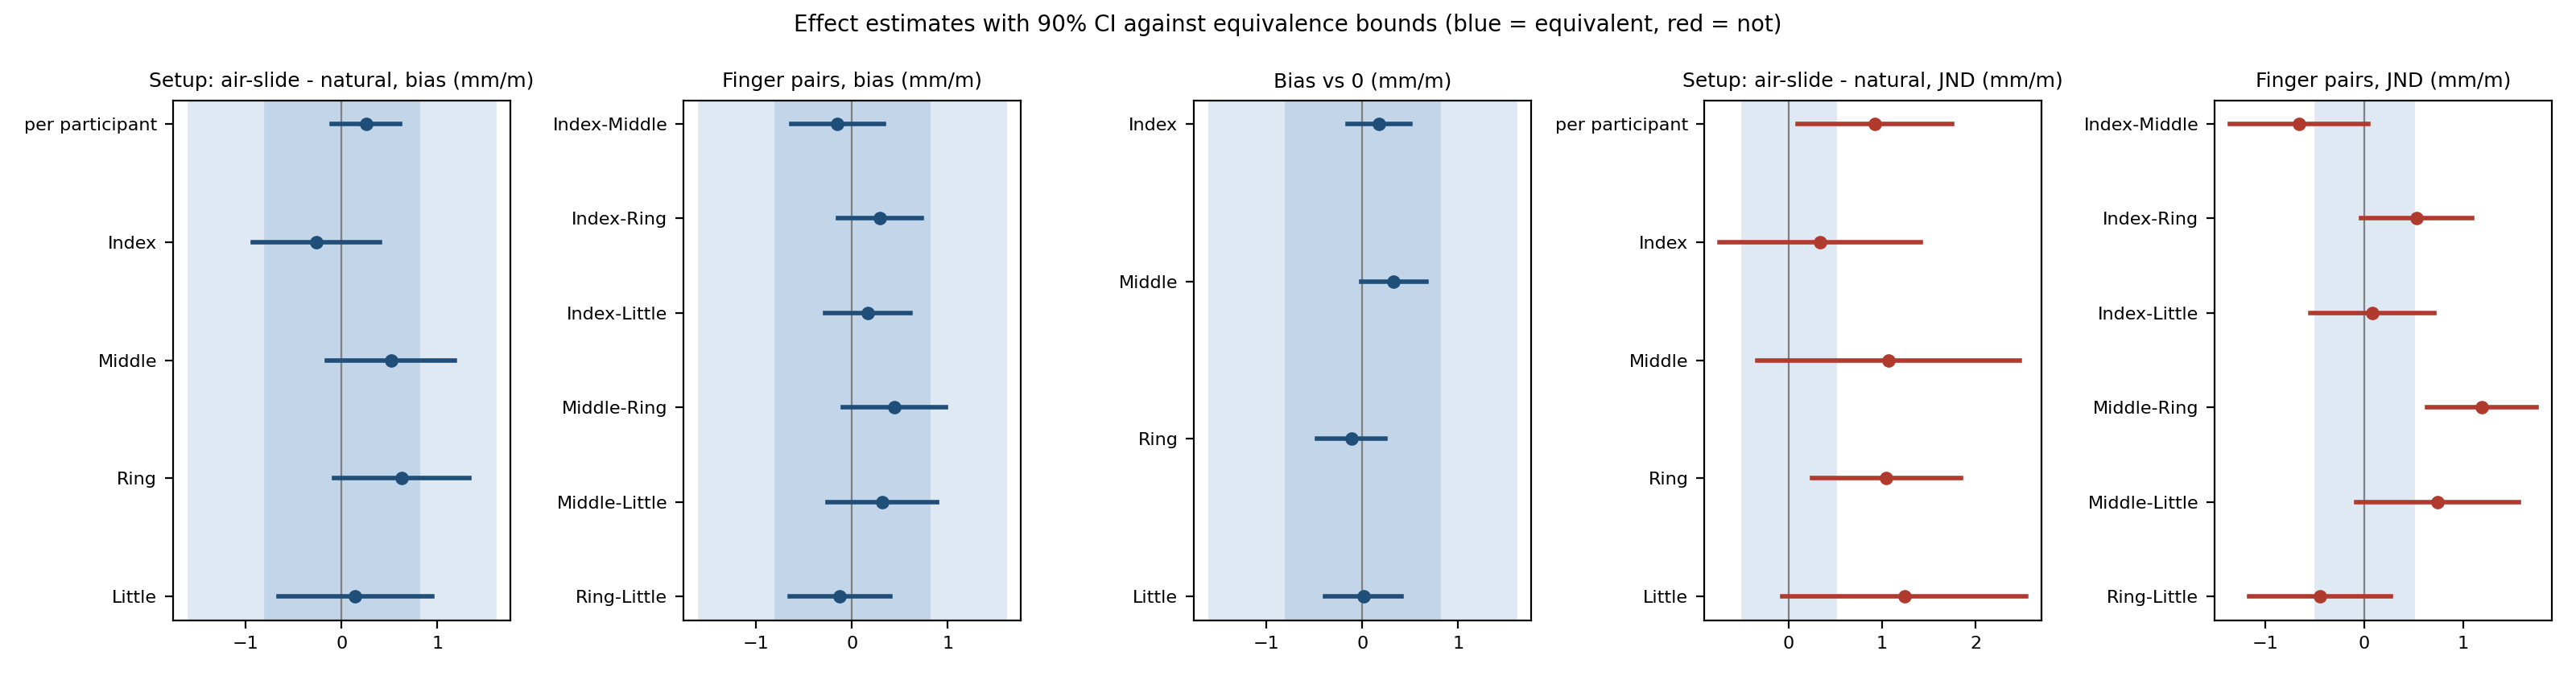

## Results paragraph (after the mixed-design ANOVA)

Because a non-significant ANOVA cannot establish the absence of an effect, we tested equivalence with two one-sided tests (TOST; Lakens, 2017) on the per-participant fits (N = 39; 20 air-slide, 19 natural). Bounds were pre-specified in perceptual units: +/-1 JND (+/-1.6 mm/m; median per-participant JND = 1.61 mm/m) for PSE bias, with +/-0.5 JND (+/-0.8 mm/m) as a stricter secondary bound, and +/-0.5 mm/m (about 30% of the JND) or a x1.3 ratio for JND. Setup comparisons used Welch's t with Welch-Satterthwaite degrees of freedom (Delacre et al., 2017), finger pairs used paired TOSTs with Holm correction, and equivalence was declared when the 90% CI lay within the bounds.

PSE bias was statistically equivalent between setups within +/-1 JND (air-slide minus natural = 0.25 mm/m, 90% CI [-0.10, 0.61], t(34.9) = -6.33, p_TOST < .001) and across all six finger pairs (Holm-corrected p_TOST max < .001). Each finger's bias was equivalent to zero within +/-1 JND (all p_TOST < .001). 
For JND, the setup difference was 0.92 mm/m (90% CI [0.09, 1.75], p_TOST = 0.803 at +/-0.5 mm/m; ratio 1.51, 90% CI [1.01, 2.25], p_TOST = 0.732 at x1.3), so equivalence could not be established; across finger pairs 0/6 (absolute) and 0/6 (ratio) passed.

Finger pairs whose JND differed (90% CI excluding zero): Middle-Ring 1.19 mm/m [0.64, 1.74].

Bayes factors complemented the TOST: for the per-participant setup comparison BF01 = 1.82 (bias) and 1.00 (log JND) with the default JZS prior (r = 0.707; over r = 0.35-1.0: 1.33-2.29 for bias). Paired JZS Bayes factors for the six finger pairs ranged over BF01 = 2.38-5.35 for bias and 0.90-4.96 for log JND (smallest: Middle-Ring). [Omnibus inclusion BF01 for Finger and Setup x Finger: fill from JASP using results/for_jasp_wide.csv.]

With 20 vs 19 participants and the observed SDs, the design had 80% power to detect a setup difference of 0.62 mm/m in bias and 1.42 mm/m in JND.


## Discussion sentence

Use 'evidence for equivalence' only where the TOST passed (bias, within one JND), 'evidence for the null' where only the Bayes factor supports it, and never 'proved no difference'.


Outputs in C:\Users\user\BIO MEDICAL ROBOTICS Dropbox\Elisheva Shiri Decktor\BGU\Codes\Parallel_Heptics\analysis\tost_equivalence\results : ['bf_inclusion.csv', 'bf_pairs.csv', 'bf_ttest.csv', 'equivalence_forest.png', 'for_jasp_wide.csv', 'mde.csv', 'pairs.csv', 'report_sentences.md', 'setup.csv', 'step0.csv', 'step2.csv', 'verdict.csv', 'zero.csv']


In [10]:
res = T.run(verbose=False)
from IPython.display import Image, display, Markdown
display(Image(res["figure"]))
display(Markdown(res["report"]))
print("Outputs in", T.OUT_DIR, ":", sorted(os.listdir(T.OUT_DIR)))


## References

* Lakens, D. (2017). Equivalence tests: A practical primer for t tests, correlations, and meta-analyses. *Social Psychological and Personality Science, 8*(4), 355-362. doi:10.1177/1948550617697177
* Delacre, M., Lakens, D., & Leys, C. (2017). Why psychologists should by default use Welch's t-test instead of Student's t-test. *International Review of Social Psychology, 30*(1), 92-101. doi:10.5334/irsp.82
* Welch, B. L. (1947). The generalization of 'Student's' problem when several different population variances are involved. *Biometrika, 34*, 28-35.
* Schuirmann, D. J. (1987). A comparison of the two one-sided tests procedure and the power approach for assessing the equivalence of average bioavailability. *Journal of Pharmacokinetics and Biopharmaceutics, 15*, 657-680.
* Rouder, J. N., Speckman, P. L., Sun, D., Morey, R. D., & Iverson, G. (2009). Bayesian t tests for accepting and rejecting the null hypothesis. *Psychonomic Bulletin & Review, 16*, 225-237.
